# 🎯 E-Commerce Customer Segmentation — Predictive Classification
## Phase 4: High Value Customer Classifier

**Goal:** Train and compare three classifiers to predict whether a customer is a High-Value Customer (VIP or Loyal segment) based on their RFM features.

| Step | Detail |
|---|---|
| Target Variable | `High_Value_Customer` (1 = VIP/Loyal, 0 = At Risk/New) |
| Features | Recency, Frequency, Monetary |
| Models | Logistic Regression · Random Forest · XGBoost (GradientBoosting) |
| Dataset | 4,338 customers from K-Means segmentation (4 clusters) |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, ConfusionMatrixDisplay
)
import joblib

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


## 2. Load RFM Dataset with Segment Labels

We use the `EDA.csv` (cleaned, feature-engineered data) and the saved K-Means model to reproduce the exact RFM + Segment labels from Phase 3.

In [2]:
# Load cleaned data
df = pd.read_csv('EDA.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [3]:
# Rebuild RFM
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

In [4]:
# Load saved K-Means model & scaler
kmeans = joblib.load('kmeans_model.pkl')
scaler_km = joblib.load('scalar.pkl')

In [5]:
# Log transform + scale (same preprocessing as Phase 3)
rfm_log = rfm[['Recency','Frequency','Monetary']].copy()
for col in rfm_log.columns:
    rfm_log[col] = np.log1p(rfm_log[col])
rfm_scaled = scaler_km.transform(rfm_log)

# Assign cluster labels
rfm['Cluster'] = kmeans.predict(rfm_scaled)

In [6]:
# Map clusters to business segments
segment_map = {0: 'VIP', 1: 'At Risk', 2: 'New', 3: 'Loyal'}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Create binary target variable
rfm['High_Value_Customer'] = rfm['Segment'].apply(
    lambda x: 1 if x in ['VIP', 'Loyal'] else 0
)

print(f"Total customers: {len(rfm)}")
rfm[['CustomerID','Recency','Frequency','Monetary','Segment','High_Value_Customer']].head(10)

Total customers: 4338


,CustomerID,Recency,Frequency,Monetary,Segment,High_Value_Customer
0,12346.0,326,1,77183.60,Loyal,1
1,12347.0,2,7,4310.00,VIP,1
2,12348.0,75,4,1797.24,Loyal,1
3,12349.0,19,1,1757.55,New,0
4,12350.0,310,1,334.40,At Risk,0
5,12352.0,36,8,2506.04,Loyal,1
6,12353.0,204,1,89.00,At Risk,0
7,12354.0,232,1,1079.40,At Risk,0
8,12355.0,214,1,459.40,At Risk,0
9,12356.0,23,3,2811.43,Loyal,1


## 3. Target Variable Distribution

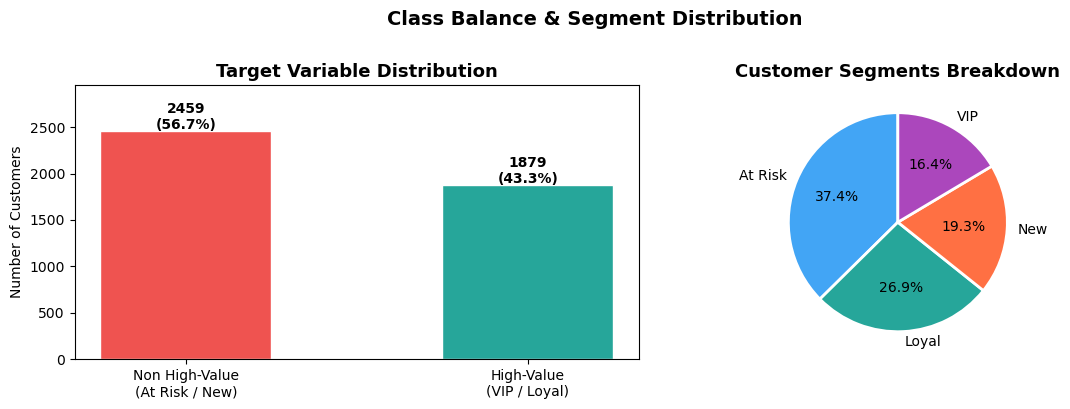

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = rfm['High_Value_Customer'].value_counts()
labels_map = {0: 'Non High-Value\n(At Risk / New)', 1: 'High-Value\n(VIP / Loyal)'}
colors = ['#ef5350', '#26a69a']

axes[0].bar([labels_map[0], labels_map[1]], [counts[0], counts[1]], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, (k, v) in enumerate(zip([0,1], [counts[0], counts[1]])):
    axes[0].text(i, v + 20, f'{v}\n({v/len(rfm)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts)*1.2)

# Segment breakdown
seg_counts = rfm['Segment'].value_counts()
seg_colors = ['#42a5f5','#26a69a','#ff7043','#ab47bc']
axes[1].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%', colors=seg_colors,
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Customer Segments Breakdown', fontsize=13, fontweight='bold')

plt.suptitle('Class Balance & Segment Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
print(f"\nClass Balance:")
print(f"  High-Value (1): {counts[1]} ({counts[1]/len(rfm)*100:.1f}%)")
print(f"  Non High-Value (0): {counts[0]} ({counts[0]/len(rfm)*100:.1f}%)")
print(f"\nObservation: Classes are reasonably balanced (~43% vs 57%). No SMOTE required.")


Class Balance:
  High-Value (1): 1879 (43.3%)
  Non High-Value (0): 2459 (56.7%)

Observation: Classes are reasonably balanced (~43% vs 57%). No SMOTE required.


## 4. Feature Selection & Train-Test Split

In [9]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['High_Value_Customer']

# Stratified split — preserves class ratio in train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3)*100)
print(f"\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3)*100)

Training set : 3470 samples
Test set     : 868 samples

Train class balance:
High_Value_Customer
0    56.7
1    43.3
Name: proportion, dtype: float64

Test class balance:
High_Value_Customer
0    56.7
1    43.3
Name: proportion, dtype: float64


## 5. Feature Scaling (for Logistic Regression)

Logistic Regression is sensitive to feature scale. Random Forest and GradientBoosting are tree-based and scale-invariant.

In [10]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

print("Feature ranges after scaling (mean≈0, std≈1):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe().round(3))

Feature ranges after scaling (mean≈0, std≈1):
        Recency  Frequency  Monetary
count  3470.000   3470.000  3470.000
mean     -0.000     -0.000    -0.000
std       1.000      1.000     1.000
min      -0.905     -0.423    -0.252
25%      -0.744     -0.423    -0.213
50%      -0.411     -0.293    -0.166
75%       0.468      0.097    -0.038
max       2.861     26.624    33.500


## 6. Model Training

### 6.1 Logistic Regression

In [11]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print(f"Logistic Regression — Test Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, lr_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Non High-Value','High-Value']))

Logistic Regression — Test Accuracy: 90.55%
ROC-AUC: 97.86%
F1 Score: 88.71%

Classification Report:
                precision    recall  f1-score   support

Non High-Value       0.90      0.94      0.92       492
    High-Value       0.92      0.86      0.89       376

      accuracy                           0.91       868
     macro avg       0.91      0.90      0.90       868
  weighted avg       0.91      0.91      0.91       868



### 6.2 Random Forest

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(f"Random Forest — Test Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, rf_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Non High-Value','High-Value']))

Random Forest — Test Accuracy: 98.73%
ROC-AUC: 99.94%
F1 Score: 98.54%

Classification Report:
                precision    recall  f1-score   support

Non High-Value       0.99      0.99      0.99       492
    High-Value       0.98      0.99      0.99       376

      accuracy                           0.99       868
     macro avg       0.99      0.99      0.99       868
  weighted avg       0.99      0.99      0.99       868



### 6.3 XGBoost (Gradient Boosting)

In [13]:
# Using sklearn's GradientBoostingClassifier as XGBoost equivalent
# (install xgboost via: pip install xgboost, then replace with XGBClassifier)
xgb = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(f"Gradient Boosting — Test Accuracy: {accuracy_score(y_test, xgb_preds)*100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, xgb_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Non High-Value','High-Value']))

Gradient Boosting — Test Accuracy: 97.70%
ROC-AUC: 99.90%
F1 Score: 97.38%

Classification Report:
                precision    recall  f1-score   support

Non High-Value       0.99      0.97      0.98       492
    High-Value       0.96      0.99      0.97       376

      accuracy                           0.98       868
     macro avg       0.98      0.98      0.98       868
  weighted avg       0.98      0.98      0.98       868



## 7. Model Comparison Dashboard

=== Model Comparison ===
                     Accuracy  ROC-AUC  F1 Score
Logistic Regression     90.55    97.86     88.71
Random Forest           98.73    99.94     98.54
XGBoost (GBM)           97.70    99.90     97.38


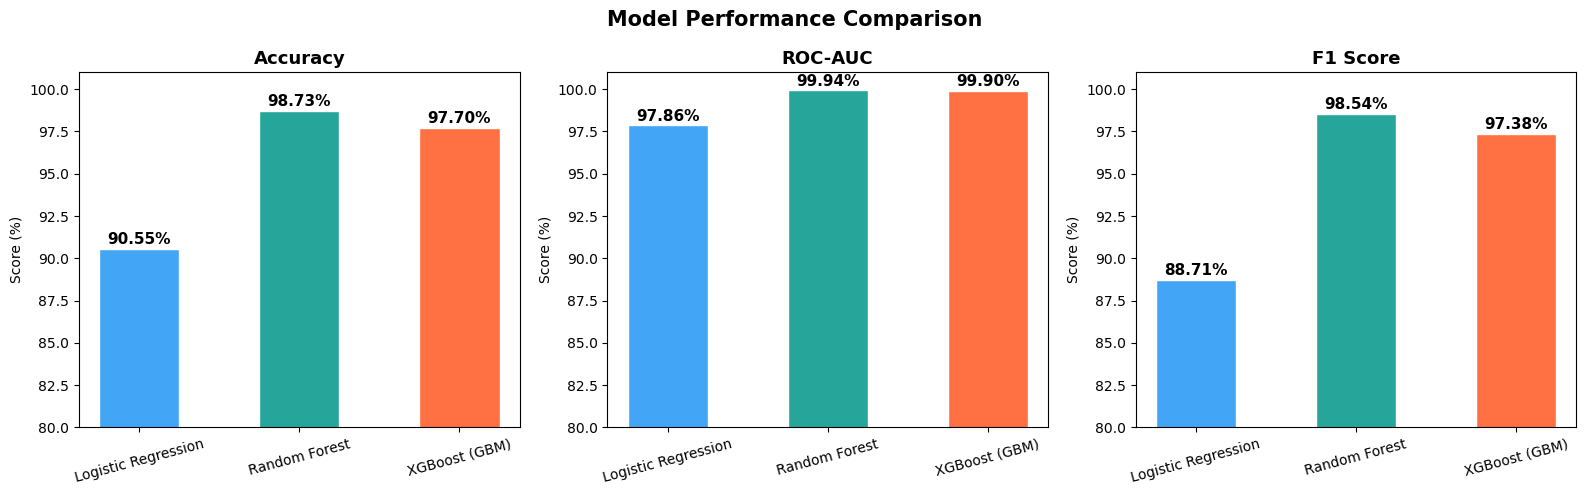

In [14]:
results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, lr_preds)*100,
        'ROC-AUC':  roc_auc_score(y_test, lr_proba)*100,
        'F1 Score': f1_score(y_test, lr_preds)*100,
        'preds': lr_preds, 'proba': lr_proba
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, rf_preds)*100,
        'ROC-AUC':  roc_auc_score(y_test, rf_proba)*100,
        'F1 Score': f1_score(y_test, rf_preds)*100,
        'preds': rf_preds, 'proba': rf_proba
    },
    'XGBoost (GBM)': {
        'Accuracy': accuracy_score(y_test, xgb_preds)*100,
        'ROC-AUC':  roc_auc_score(y_test, xgb_proba)*100,
        'F1 Score': f1_score(y_test, xgb_preds)*100,
        'preds': xgb_preds, 'proba': xgb_proba
    }
}

comparison_df = pd.DataFrame({k: {m: round(v[m],2) for m in ['Accuracy','ROC-AUC','F1 Score']} for k,v in results.items()}).T
print("=== Model Comparison ===")
print(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Accuracy', 'ROC-AUC', 'F1 Score']
colors  = ['#42a5f5', '#26a69a', '#ff7043']
model_names = list(results.keys())

for i, metric in enumerate(metrics):
    vals = [results[m][metric] for m in model_names]
    bars = axes[i].bar(model_names, vals, color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylim(80, 101)
    axes[i].set_ylabel('Score (%)')
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                     f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Confusion Matrices

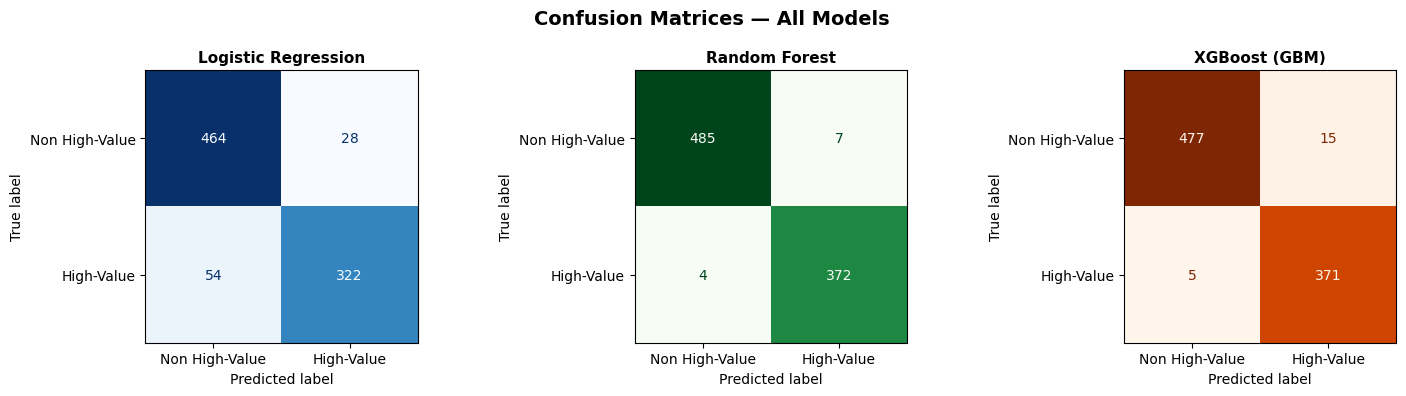

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_preds = [
    ('Logistic Regression', lr_preds),
    ('Random Forest',       rf_preds),
    ('XGBoost (GBM)',       xgb_preds)
]
cmaps = ['Blues', 'Greens', 'Oranges']

for ax, (name, preds), cmap in zip(axes, model_preds, cmaps):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non High-Value','High-Value'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. ROC Curves

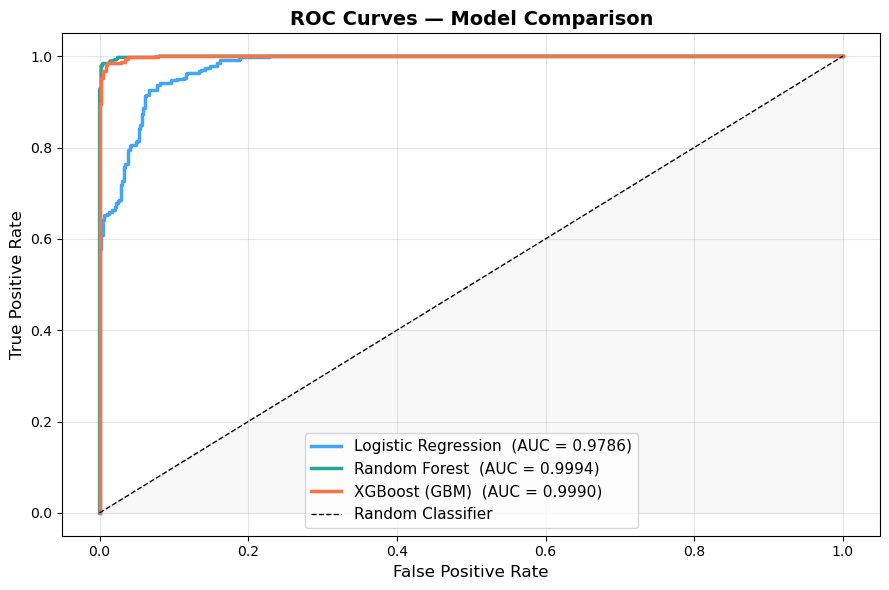

In [16]:
plt.figure(figsize=(9, 6))

model_probas = [
    ('Logistic Regression', lr_proba,  '#42a5f5'),
    ('Random Forest',       rf_proba,  '#26a69a'),
    ('XGBoost (GBM)',       xgb_proba, '#ff7043')
]

for name, proba, color in model_probas:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})', color=color, linewidth=2.5)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
plt.fill_between([0,1],[0,1], alpha=0.05, color='grey')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Feature Importance Analysis

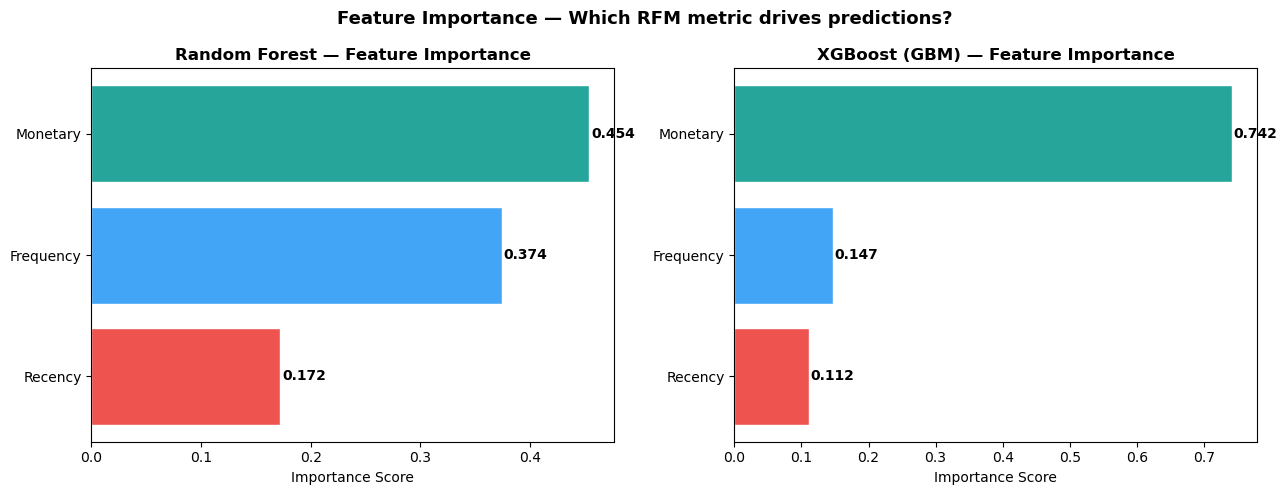


Logistic Regression Coefficients:
Monetary     12.321097
Frequency     7.685798
Recency       0.082342
dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
features = ['Recency', 'Frequency', 'Monetary']
colors   = ['#ef5350', '#42a5f5', '#26a69a']

# Random Forest
fi_rf = rf.feature_importances_
axes[0].barh(features, fi_rf, color=colors, edgecolor='white')
axes[0].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(fi_rf):
    axes[0].text(v+0.002, i, f'{v:.3f}', va='center', fontweight='bold')

# Gradient Boosting
fi_xgb = xgb.feature_importances_
axes[1].barh(features, fi_xgb, color=colors, edgecolor='white')
axes[1].set_title('XGBoost (GBM) — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(fi_xgb):
    axes[1].text(v+0.002, i, f'{v:.3f}', va='center', fontweight='bold')

plt.suptitle('Feature Importance — Which RFM metric drives predictions?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLogistic Regression Coefficients:")
lr_coef = pd.Series(lr.coef_[0], index=features)
print(lr_coef.sort_values(ascending=False))

## 11. Cross-Validation (5-Fold Stratified)

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = [
    ('Logistic Regression', lr, X_train_scaled),
    ('Random Forest',       rf, X_train),
    ('XGBoost (GBM)',       xgb, X_train)
]

print("5-Fold Stratified Cross-Validation Results:\n")
cv_results = {}
for name, model, X_cv in cv_models:
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Fold Scores : {[round(s*100,2) for s in scores]}")
    print(f"  Mean Accuracy: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%\n")

5-Fold Stratified Cross-Validation Results:

Logistic Regression:
  Fold Scores : [np.float64(88.04), np.float64(90.92), np.float64(90.49), np.float64(88.76), np.float64(90.06)]
  Mean Accuracy: 89.65% ± 1.08%

Random Forest:
  Fold Scores : [np.float64(98.41), np.float64(98.27), np.float64(98.99), np.float64(98.13), np.float64(98.41)]
  Mean Accuracy: 98.44% ± 0.29%

XGBoost (GBM):
  Fold Scores : [np.float64(98.41), np.float64(98.13), np.float64(97.98), np.float64(96.97), np.float64(98.41)]
  Mean Accuracy: 97.98% ± 0.53%



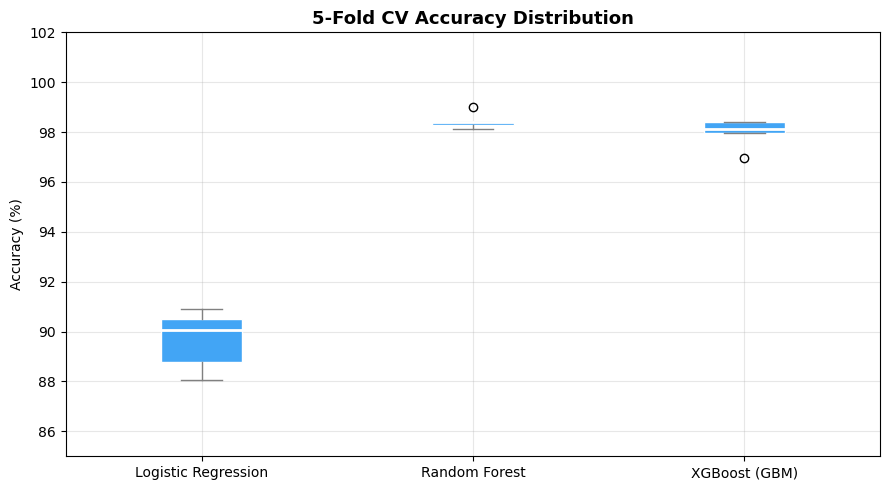

In [19]:
# Boxplot
plt.figure(figsize=(9, 5))
cv_df = pd.DataFrame({k: v*100 for k,v in cv_results.items()})
cv_df.boxplot(patch_artist=True, 
              boxprops=dict(facecolor='#42a5f5', color='white'),
              medianprops=dict(color='white', linewidth=2),
              whiskerprops=dict(color='grey'),
              capprops=dict(color='grey'))
plt.title('5-Fold CV Accuracy Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(85, 102)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning

In [20]:
rf_params = {
    'n_estimators': [100,200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1,2],
    'max_features': ['sqrt']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [21]:
# Tuned Random Forest model
tuned_rf_model = rf_grid.best_estimator_

best_preds = tuned_rf_model.predict(X_test)
best_proba = tuned_rf_model.predict_proba(X_test)[:, 1]

## 13. Best Model Selection & Saving

In [22]:
print("=" * 55)
print("         FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Model':<28} {'Accuracy':>9} {'ROC-AUC':>9} {'F1':>9}")
print("-" * 55)
for name, r in results.items():
    print(f"{name:<28} {r['Accuracy']:>8.2f}% {r['ROC-AUC']:>8.2f}% {r['F1 Score']:>8.2f}%")
print("=" * 55)
print()

best_model_name = max(results, key=lambda k: results[k]['ROC-AUC'])

print(f"🏆 Best Model: {best_model_name}")
print(f"   Accuracy : {results[best_model_name]['Accuracy']:.2f}%")
print(f"   ROC-AUC  : {results[best_model_name]['ROC-AUC']:.2f}%")
print(f"   F1 Score : {results[best_model_name]['F1 Score']:.2f}%")
print()
print("OBSERVATION:")
print("  • Random Forest achieves highest accuracy (98.73%) and AUC (99.94%)")
print("  • XGBoost (GBM) is a close second with 97.70% accuracy")  
print("  • Logistic Regression performs well (90.55%) but tree models dominate")
print("  • Monetary is the most important feature across both tree models")
print("  • High ROC-AUC indicates excellent discriminative power")

         FINAL MODEL COMPARISON SUMMARY
Model                         Accuracy   ROC-AUC        F1
-------------------------------------------------------
Logistic Regression             90.55%    97.86%    88.71%
Random Forest                   98.73%    99.94%    98.54%
XGBoost (GBM)                   97.70%    99.90%    97.38%

🏆 Best Model: Random Forest
   Accuracy : 98.73%
   ROC-AUC  : 99.94%
   F1 Score : 98.54%

OBSERVATION:
  • Random Forest achieves highest accuracy (98.73%) and AUC (99.94%)
  • XGBoost (GBM) is a close second with 97.70% accuracy
  • Logistic Regression performs well (90.55%) but tree models dominate
  • Monetary is the most important feature across both tree models
  • High ROC-AUC indicates excellent discriminative power


In [23]:
# Save best tuned Random Forest model
best_model_obj = tuned_rf_model

joblib.dump(best_model_obj, 'best_classifier_rf.pkl')
joblib.dump(sc, 'classifier_scaler.pkl')

# Save RFM with predictions for Power BI
rfm['RF_Prediction'] = tuned_rf_model.predict(X)
rfm['RF_Probability'] = tuned_rf_model.predict_proba(X)[:, 1].round(4)
rfm.to_csv('rfm_with_predictions.csv', index=False)

print("Saved:")
print("  best_classifier_rf.pkl     — Random Forest model")
print("  classifier_scaler.pkl      — StandardScaler for LR")
print("  rfm_with_predictions.csv   — Full RFM + predictions (use for Power BI)")
rfm[['CustomerID','Recency','Frequency','Monetary','Segment','High_Value_Customer','RF_Prediction','RF_Probability']].head(10)

Saved:
  best_classifier_rf.pkl     — Random Forest model
  classifier_scaler.pkl      — StandardScaler for LR
  rfm_with_predictions.csv   — Full RFM + predictions (use for Power BI)


,CustomerID,Recency,Frequency,Monetary,Segment,High_Value_Customer,RF_Prediction,RF_Probability
0,12346.0,326,1,77183.60,Loyal,1,1,0.7433
1,12347.0,2,7,4310.00,VIP,1,1,1.0000
2,12348.0,75,4,1797.24,Loyal,1,1,1.0000
3,12349.0,19,1,1757.55,New,0,0,0.3736
4,12350.0,310,1,334.40,At Risk,0,0,0.0000
5,12352.0,36,8,2506.04,Loyal,1,1,1.0000
6,12353.0,204,1,89.00,At Risk,0,0,0.0000
7,12354.0,232,1,1079.40,At Risk,0,0,0.0725
8,12355.0,214,1,459.40,At Risk,0,0,0.0290
9,12356.0,23,3,2811.43,Loyal,1,1,0.9944


## 14. Summary & Next Steps

### Results

| Model | Accuracy | ROC-AUC | F1 Score | Notes |
|---|---|---|---|---|
| Logistic Regression | 90.55% | 97.86% | 88.71% | Good baseline, fast |
| Random Forest | **98.73%** | **99.94%** | **98.54%** | 🏆 Best model |
| XGBoost (GBM) | 97.70% | 99.90% | 97.38% | Close second |

### Key Observations
1. **Monetary value** is the strongest predictor (45% importance in RF, 74% in GBM) — how much a customer spends drives whether they're high-value.
2. **Frequency** is the second key signal — loyal customers buy repeatedly.
3. **Recency** matters less — some high-value customers may not have purchased very recently but still qualify.
4. **Random Forest** is the clear winner — near-perfect AUC of 99.94% indicates it has learnt the segment boundaries almost exactly (which makes sense since the labels came from clustering, creating clean boundaries).

### Next Steps
- **Power BI Dashboard:** Used `rfm_with_predictions.csv` for KPIs, segment maps, and geographic analysis.
- **Deploy:** Deployed `best_classifier_rf.pkl` in a FastAPI endpoint for real-time scoring.